In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.api import VAR
from arch import arch_model
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Input, Conv1D, Flatten, Dropout, MultiHeadAttention, LayerNormalization


In [23]:
df = pd.read_csv("Processed data]\Bitcoin.csv", parse_dates=True, index_col=0)
print(df.head())
print(df.describe())


                  open        high         low       close      volume  \
date                                                                     
2015-01-02  314.079010  315.838989  313.565002  315.032013   7860650.0   
2015-01-03  314.846008  315.149994  281.082001  281.082001  33054400.0   
2015-01-04  281.145996  287.230011  257.612000  264.195007  55629100.0   
2015-01-05  265.084015  278.341003  265.084015  274.473999  43962800.0   
2015-01-06  274.610992  287.553009  272.696014  286.188995  23245700.0   

                 rsi_7      rsi_14       cci_7      cci_14      sma_50  \
date                                                                     
2015-01-02  100.000000  100.000000  -66.666667  -66.666667  314.640503   
2015-01-03    1.938583    2.096744 -100.000000 -100.000000  303.454336   
2015-01-04    1.235506    1.375421 -110.693896 -110.693896  293.639503   
2015-01-05   21.462825   19.523695  -76.487357  -76.487357  289.806403   
2015-01-06   38.272356   34.350787  -

In [24]:
# Compute log returns
returns_df = np.log(df['close'] / df['close'].shift(1)).dropna()
returns_df = pd.DataFrame(returns_df, columns=['returns'])
returns_df.head()


,returns


In [25]:
# Load and preview your dataset
data = pd.read_csv("Processed data]\Bitcoin.csv")

# Show structure
print("Shape:", data.shape)
print("Columns:", data.columns)
print("\nSample rows:")
print(data.head())

Shape: (3130, 20)
Columns: Index(['date', 'open', 'high', 'low', 'close', 'volume', 'rsi_7', 'rsi_14',
       'cci_7', 'cci_14', 'sma_50', 'ema_50', 'sma_100', 'ema_100', 'macd',
       'bollinger', 'TrueRange', 'atr_7', 'atr_14', 'next_day_close'],
      dtype='object')

Sample rows:
         date        open        high         low       close      volume  \
0  2015-01-02  314.079010  315.838989  313.565002  315.032013   7860650.0   
1  2015-01-03  314.846008  315.149994  281.082001  281.082001  33054400.0   
2  2015-01-04  281.145996  287.230011  257.612000  264.195007  55629100.0   
3  2015-01-05  265.084015  278.341003  265.084015  274.473999  43962800.0   
4  2015-01-06  274.610992  287.553009  272.696014  286.188995  23245700.0   

        rsi_7      rsi_14       cci_7      cci_14      sma_50      ema_50  \
0  100.000000  100.000000  -66.666667  -66.666667  314.640503  314.648333   
1    1.938583    2.096744 -100.000000 -100.000000  303.454336  303.009081   
2    1.235506    1.3

In [26]:
# Augmented Dickey-Fuller Test
adf_result = adfuller(returns_df['returns'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ARCH LM Test
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(returns_df['returns'])
print("ARCH LM Test Statistic:", arch_test[0], "p-value:", arch_test[1])


ValueError: zero-size array to reduction operation maximum which has no identity

In [27]:
print(df.shape)
print(df['close'].head())
print(df['close'].isna().sum())

(3130, 19)
date
2015-01-02    315.032013
2015-01-03    281.082001
2015-01-04    264.195007
2015-01-05    274.473999
2015-01-06    286.188995
Name: close, dtype: float64
0


In [28]:
df = df.copy()
df['close'] = pd.to_numeric(df['close'], errors='coerce')
df = df.dropna(subset=['close'])

returns_df = np.log(df['close'] / df['close'].shift(1)).dropna().to_frame(name='returns')
print(returns_df.head())

             returns
date                
2015-01-03 -0.114028
2015-01-04 -0.061959
2015-01-05  0.038169
2015-01-06  0.041796
2015-01-07  0.028073


In [29]:
# Augmented Dickey-Fuller Test
adf_result = adfuller(returns_df['returns'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ARCH LM Test
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(returns_df['returns'])
print("ARCH LM Test Statistic:", arch_test[0], "p-value:", arch_test[1])

ADF Statistic: -57.22951502518514
p-value: 0.0
ARCH LM Test Statistic: 100.76706222469757 p-value: 3.8265458791335956e-17


In [30]:
# Augmented Dickey-Fuller Test
adf_result = adfuller(returns_df['returns'])
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")

# ARCH LM Test
from statsmodels.stats.diagnostic import het_arch
arch_test = het_arch(returns_df['returns'])
print("ARCH LM Test Statistic:", arch_test[0], "p-value:", arch_test[1])

# ------------------------------------------
# 📘 Jarque-Bera Test for Normality
# ------------------------------------------
import pandas as pd
import numpy as np
from scipy.stats import jarque_bera

# Example: assuming you have 'returns' column in your DataFrame
# If not yet calculated:
# returns_df['returns'] = np.log(returns_df['close_mean'] / returns_df['close_mean'].shift(1))
# returns_df = returns_df.dropna(subset=['returns'])

# Run Jarque–Bera test
jb_stat, jb_pvalue = jarque_bera(returns_df['returns'])

print("Jarque–Bera Test Results:")
print(f"JB Statistic : {jb_stat:.4f}")
print(f"p-value      : {jb_pvalue:.6f}")

# Interpretation
if jb_pvalue < 0.05:
    print("❌ Reject Null Hypothesis: The returns are not normally distributed (heavy tails detected).")
else:
    print("✅ Fail to Reject Null Hypothesis: The returns may be normally distributed.")


ADF Statistic: -57.22951502518514
p-value: 0.0
ARCH LM Test Statistic: 100.76706222469757 p-value: 3.8265458791335956e-17
Jarque–Bera Test Results:
JB Statistic : 16923.4318
p-value      : 0.000000
❌ Reject Null Hypothesis: The returns are not normally distributed (heavy tails detected).


In [31]:
scaler = MinMaxScaler()
scaled = scaler.fit_transform(returns_df)

def create_sequences(data, n_steps=10):
    X, y = [], []
    for i in range(len(data)-n_steps):
        X.append(data[i:i+n_steps])
        y.append(data[i+n_steps])
    return np.array(X), np.array(y)

n_steps = 10
X, y = create_sequences(scaled, n_steps)

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [32]:
returns_multivar = pd.concat([returns_df, df[['volume']].pct_change()], axis=1).dropna()

train_size = int(len(returns_multivar)*0.8)
train, test = returns_multivar.iloc[:train_size], returns_multivar.iloc[train_size:]

model_var = VAR(train)
results_var = model_var.fit(ic='aic')
pred_var = results_var.forecast(train.values[-results_var.k_ar:], steps=len(test))

rmse_var = np.sqrt(mean_squared_error(test, pred_var))
r2_var = r2_score(test, pred_var)
print(f"VAR → RMSE: {rmse_var:.5f}, R²: {r2_var:.4f}")

VAR → RMSE: 0.23482, R²: -0.0057


In [33]:
import pandas as pd
import numpy as np
from arch import arch_model
from scipy import stats

# -------------------------------
# 1️⃣ Prepare returns
# -------------------------------
returns_df['returns'] = pd.to_numeric(returns_df['returns'], errors='coerce')
returns_df = returns_df.dropna(subset=['returns'])
returns = returns_df['returns'] * 100

# -------------------------------
# 2️⃣ Fit EGARCH-GED model
# -------------------------------
model_egarch = arch_model(returns, vol='EGARCH', p=1, q=1, dist='ged')
res_egarch = model_egarch.fit(disp="off")

# Compute standard errors, t-values, p-values
params = res_egarch.params
std_err = res_egarch.std_err  # correct attribute
t_values = params / std_err
p_values = 2 * (1 - stats.norm.cdf(np.abs(t_values)))

egarch_results = pd.DataFrame({
    'Coefficient': params,
    'Std. Error': std_err,
    't-value': t_values,
    'p-value': p_values
})

egarch_results.to_csv("BITCOIN_EGARCH_results.csv", index=True)
print("EGARCH-GED Results:")
print(egarch_results)
print("EGARCH Log-Likelihood:", res_egarch.loglikelihood)

# -------------------------------
# 3️⃣ Fit TARCH-GED model
# -------------------------------
model_tarch = arch_model(returns, vol='TARCH', p=1, o=1, q=1, dist='ged')
res_tarch = model_tarch.fit(disp="off")

params = res_tarch.params
std_err = res_tarch.std_err
t_values = params / std_err
p_values = 2 * (1 - stats.norm.cdf(np.abs(t_values)))

tarch_results = pd.DataFrame({
    'Coefficient': params,
    'Std. Error': std_err,
    't-value': t_values,
    'p-value': p_values
})

tarch_results.to_csv("TARCH_results.csv", index=True)
print("\nTARCH-GED Results:")
print(tarch_results)
print("TARCH Log-Likelihood:", res_tarch.loglikelihood)

EGARCH-GED Results:
          Coefficient  Std. Error     t-value   p-value
mu           0.126816    0.277071    0.457702  0.647167
omega        0.091805    0.022645    4.054035  0.000050
alpha[1]     0.231846    0.027781    8.345471  0.000000
beta[1]      0.969299    0.008178  118.519110  0.000000
nu           1.010000    0.049931   20.227987  0.000000
EGARCH Log-Likelihood: -7898.341931282278


ValueError: Unknown model type in vol

In [34]:
model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(n_steps, 1)),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

y_pred_lstm = model_lstm.predict(X_test)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f"LSTM → RMSE: {rmse_lstm:.5f}, R²: {r2_lstm:.4f}")

c:\Users\HP\anaconda3\envs\tf_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - loss: 0.0453 - val_loss: 0.0036
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0038
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0039
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0038 - val_loss: 0.0036
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0

In [ ]:
inputs = Input(shape=(n_steps, 1))
x = Conv1D(64, kernel_size=3, dilation_rate=1, activation='relu', padding='causal')(inputs)
x = Conv1D(64, kernel_size=3, dilation_rate=2, activation='relu', padding='causal')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)

model_tcn = Model(inputs, outputs)
model_tcn.compile(optimizer='adam', loss='mse')
model_tcn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

y_pred_tcn = model_tcn.predict(X_test)
rmse_tcn = np.sqrt(mean_squared_error(y_test, y_pred_tcn))
r2_tcn = r2_score(y_test, y_pred_tcn)
print(f"TCN → RMSE: {rmse_tcn:.5f}, R²: {r2_tcn:.4f}")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.0289 - val_loss: 0.0037
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0036 - val_loss: 0.0041
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.0035 - val_loss: 0.0037
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0035 - val_loss: 0.0039
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0035 - val_loss: 0.0036
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0035 - val_loss: 0.0054
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

ValueError: continuous is not supported

In [36]:
# Use EGARCH volatility as additional input feature
egarch_forecast = res_egarch.conditional_volatility
hybrid_data = pd.concat([returns_df, egarch_forecast.rename("sigma")], axis=1).dropna()
scaled_hybrid = scaler.fit_transform(hybrid_data)

Xh, yh = create_sequences(scaled_hybrid, n_steps)
Xh_train, Xh_test = Xh[:split], Xh[split:]
yh_train, yh_test = yh[:split], yh[split:]

# Hybrid Attention Network
inputs = Input(shape=(n_steps, 2))
attn_out = MultiHeadAttention(num_heads=4, key_dim=16)(inputs, inputs)
attn_out = LayerNormalization()(attn_out)
x = Flatten()(attn_out)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
outputs = Dense(2)(x)

hybrid_model = Model(inputs, outputs)
hybrid_model.compile(optimizer='adam', loss='mse')
hybrid_model.fit(Xh_train, yh_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 0.0888 - val_loss: 0.0125
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0284 - val_loss: 0.0134
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0244 - val_loss: 0.0068
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0194 - val_loss: 0.0065
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0169 - val_loss: 0.0050
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0141 - val_loss: 0.0040
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0124 - val_loss: 0.0049
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0116 - val_loss: 0.0040
Epoch 9/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0104 - val_loss: 0.0035
Epoch 10/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0096 - val_loss: 0.0036
Epoch 11/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0087 - val_loss: 0.0032
Epoch 12/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.

In [37]:
inputs = Input(shape=(n_steps, 1))
x = Conv1D(64, kernel_size=3, dilation_rate=1, activation='relu', padding='causal')(inputs)
x = Conv1D(64, kernel_size=3, dilation_rate=2, activation='relu', padding='causal')(x)
x = Flatten()(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(1)(x)

model_tcn = Model(inputs, outputs)
model_tcn.compile(optimizer='adam', loss='mse')
model_tcn.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.1, verbose=1)

y_pred_tcn = model_tcn.predict(X_test)
rmse_tcn = np.sqrt(mean_squared_error(y_test, y_pred_tcn))
r2_tcn = r2_score(y_test, y_pred_tcn)
print(f"TCN → RMSE: {rmse_tcn:.5f}, R²: {r2_tcn:.4f}")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 0.0227 - val_loss: 0.0037
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.0047
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0038 - val_loss: 0.0044
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0038 - val_loss: 0.0037
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0036 - val_loss: 0.0037
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.0037
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0037 - val_loss: 0.0036
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0

In [49]:
y_pred_hybrid = hybrid_model.predict(Xh_test)
rmse_hybrid = np.sqrt(mean_squared_error(yh_test, y_pred_hybrid))
r2_hybrid = r2_score(yh_test, y_pred_hybrid)

print(f"Hybrid → RMSE: {rmse_hybrid:.5f}, R²: {r2_hybrid:.4f}")

# Comparison summary
print("\n==== Model Benchmark Summary ====")
print(f"VAR       : RMSE={rmse_var:.5f}, R²={r2_var:.4f}")
print(f"LSTM      : RMSE={rmse_lstm:.5f}, R²={r2_lstm:.4f}")
print(f"TCN       : RMSE={rmse_tcn:.5f}, R²={r2_tcn:.4f}")
print(f"HYBRID    : RMSE={rmse_hybrid:.5f}, R²={r2_hybrid:.4f}")


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step
Hybrid → RMSE: 0.03860, R²: 0.3407

==== Model Benchmark Summary ====
VAR       : RMSE=0.23482, R²=-0.0057
LSTM      : RMSE=0.04620, R²=-0.0764
TCN       : RMSE=0.04611, R²=-0.0721
HYBRID    : RMSE=0.03860, R²=0.3407


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

# If your model outputs multiple values, take one column (e.g., first target)
yh_test_flat = yh_test[:, 0] if yh_test.ndim > 1 else yh_test
y_pred_hybrid_flat = y_pred_hybrid[:, 0] if y_pred_hybrid.ndim > 1 else y_pred_hybrid

# 1️⃣ Define a tail-risk threshold (e.g., 5% quantile for losses)
threshold = np.percentile(yh_test_flat, 5)

# 2️⃣ Convert continuous outputs into binary events
y_true_class = (yh_test_flat < threshold).astype(int)
y_pred_class = (y_pred_hybrid_flat < threshold).astype(int)

# 3️⃣ Compute metrics
precision = precision_score(y_true_class, y_pred_class, zero_division=0)
recall = recall_score(y_true_class, y_pred_class, zero_division=0)
f1 = f1_score(y_true_class, y_pred_class, zero_division=0)

print("\n==== Tail-Risk Classification Metrics (Hybrid Model) ====")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")



==== Tail-Risk Classification Metrics (Hybrid Model) ====
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000


In [43]:
dir()

['Conv1D',
 'Dense',
 'Dropout',
 'Flatten',
 'In',
 'Input',
 'LSTM',
 'LayerNormalization',
 'MinMaxScaler',
 'Model',
 'MultiHeadAttention',
 'Out',
 'Sequential',
 'VAR',
 'X',
 'X_test',
 'X_train',
 'Xh',
 'Xh_test',
 'Xh_train',
 '_',
 '_18',
 '_24',
 '_36',
 '_4',
 '__',
 '___',
 '__builtin__',
 '__builtins__',
 '__doc__',
 '__loader__',
 '__name__',
 '__package__',
 '__spec__',
 '__vsc_ipynb_file__',
 '_dh',
 '_i',
 '_i1',
 '_i10',
 '_i11',
 '_i12',
 '_i13',
 '_i14',
 '_i15',
 '_i16',
 '_i17',
 '_i18',
 '_i19',
 '_i2',
 '_i20',
 '_i21',
 '_i22',
 '_i23',
 '_i24',
 '_i25',
 '_i26',
 '_i27',
 '_i28',
 '_i29',
 '_i3',
 '_i30',
 '_i31',
 '_i32',
 '_i33',
 '_i34',
 '_i35',
 '_i36',
 '_i37',
 '_i38',
 '_i39',
 '_i4',
 '_i40',
 '_i41',
 '_i42',
 '_i43',
 '_i5',
 '_i6',
 '_i7',
 '_i8',
 '_i9',
 '_ih',
 '_ii',
 '_iii',
 '_oh',
 'adf_result',
 'adfuller',
 'arch_model',
 'arch_test',
 'attn_out',
 'create_sequences',
 'data',
 'df',
 'egarch_forecast',
 'egarch_results',
 'exit',
 'f1_s

In [44]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# ==========================================
# 1️⃣ True values (update this line if needed)
# ==========================================
# Replace 'y_test' with your actual test target variable
# or use test.iloc[:,0].values if you used VAR train/test split
y_true = np.array(y_test).flatten()

# ==========================================
# 2️⃣ Predictions from all models
# ==========================================
predictions = {
    "VAR": np.array(pred_var).flatten()[:len(y_true)],
    "LSTM": np.array(y_pred_lstm).flatten()[:len(y_true)],
    "TCN": np.array(y_pred_tcn).flatten()[:len(y_true)],
    "HYBRID": np.array(y_pred_hybrid).flatten()[:len(y_true)]
}

# ==========================================
# 3️⃣ Convert to binary (e.g., for downside risk or classification)
# ==========================================
# Define a threshold — here, 5th percentile of true values
threshold = np.percentile(y_true, 5)
y_true_binary = (y_true < threshold).astype(int)

# ==========================================
# 4️⃣ Compute metrics for each model
# ==========================================
results = []
for name, y_pred in predictions.items():
    y_pred_binary = (y_pred < threshold).astype(int)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    results.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4)
    })

# ==========================================
# 5️⃣ Display and save results
# ==========================================
results_df = pd.DataFrame(results)
print("\n==== Model Precision, Recall & F1-score Comparison ====\n")
print(results_df.to_string(index=False))

# Optional: Save to CSV
results_df.to_csv("model_f1_precision_recall.csv", index=False)
print("\n✅ Results saved to 'model_f1_precision_recall.csv'")


NameError: name 'y_pred_hybrid' is not defined

In [46]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# === Ensure y_test exists ===
y_true = np.array(X_test).flatten()

# === Predictions from models ===
predictions = {
    "VAR": np.array(pred_var).flatten()[:len(y_true)],
    "LSTM": np.array(y_pred_lstm).flatten(),
    "TCN": np.array(y_pred_tcn).flatten(),
    "HYBRID": np.array(X_test).flatten()
}

# === Define shortfall threshold (VaR-based) ===
threshold = np.percentile(y_true, 5)
y_true_binary = (y_true < threshold).astype(int)

# === Compute metrics ===
metrics = []
for name, y_pred in predictions.items():
    y_pred_binary = (y_pred < threshold).astype(int)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    metrics.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    })

# === Show comparison ===
results_df = pd.DataFrame(metrics)
print("\n==== Precision, Recall, F1 Comparison ====\n")
print(results_df.to_string(index=False))


ValueError: Found input variables with inconsistent numbers of samples: [6240, 1252]

In [47]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# === True values (actual returns or volatility) ===
y_true = np.array(X_test).flatten()   # make sure shape is 1D

# === Predicted values from each model ===
predictions = {
    "VAR": np.array(pred_var).flatten()[:len(y_true)],  # VAR forecast
    "LSTM": np.array(y_pred_lstm).flatten(),
    "TCN": np.array(y_pred_tcn).flatten(),
    "HYBRID": np.array(y_pred_hybrid).flatten()
}

# === Define shortfall threshold (95% VaR) ===
threshold = np.percentile(y_true, 5)   # 5% tail (left side)
y_true_binary = (y_true < threshold).astype(int)  # 1 = shortfall event

metrics = []

# === Compute metrics for each model ===
for name, y_pred in predictions.items():
    y_pred_binary = (y_pred < threshold).astype(int)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    metrics.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    })

# === Convert to DataFrame and display ===
results_df = pd.DataFrame(metrics)
print("\n==== Classification Metric Comparison ====\n")
print(results_df.to_string(index=False))


NameError: name 'y_pred_hybrid' is not defined

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score

# === True values (actual returns or volatility) ===
y_true = np.array(y_test).flatten()   # make sure shape is 1D

# === Predicted values from each model ===
predictions = {
    "VAR": np.array(pred_var).flatten()[:len(y_true)],  # VAR forecast
    "LSTM": np.array(y_pred_lstm).flatten(),
    "TCN": np.array(y_pred_tcn).flatten(),
    "HYBRID": np.array(y_pred_hybrid).flatten()
}

# === Define shortfall threshold (95% VaR) ===
threshold = np.percentile(y_true, 5)   # 5% tail (left side)
y_true_binary = (y_true < threshold).astype(int)  # 1 = shortfall event

metrics = []

# === Compute metrics for each model ===
for name, y_pred in predictions.items():
    y_pred_binary = (y_pred < threshold).astype(int)
    precision = precision_score(y_true_binary, y_pred_binary, zero_division=0)
    recall = recall_score(y_true_binary, y_pred_binary, zero_division=0)
    f1 = f1_score(y_true_binary, y_pred_binary, zero_division=0)
    metrics.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4)
    })

# === Convert to DataFrame and display ===
results_df = pd.DataFrame(metrics)
print("\n==== Classification Metric Comparison ====\n")
print(results_df.to_string(index=False))


NameError: name 'y_test' is not defined

In [48]:
from scipy.stats import gennorm

alpha = 0.05  # 95% confidence
volatility = y_pred_hybrid[:,0]  # predicted volatility component

# GED quantile
nu = 1.5  # shape parameter (tuned from EGARCH fit)
quantile = gennorm.ppf(alpha, nu)
VaR = -volatility * quantile
ES = VaR * (nu + quantile**2) / (nu - 1)

plt.plot(VaR, label='VaR')
plt.plot(ES, label='ES')
plt.legend()
plt.title("Hybrid Model VaR and ES")
plt.show()


NameError: name 'y_pred_hybrid' is not defined

In [18]:
def kupiec_test(returns, VaR, alpha=0.05):
    exceptions = (returns.values < -VaR)
    N = len(exceptions)
    x = exceptions.sum()
    pi = x / N
    LR = -2 * (np.log(((1-alpha)**(N-x) * alpha**x) / ((1-pi)**(N-x) * pi**x)))
    return LR, 1 - chi2.cdf(LR, df=1)

from scipy.stats import chi2
LR, pval = kupiec_test(returns_df['returns'].iloc[-len(VaR):], VaR)
print(f"Kupiec LR: {LR:.3f}, p-value: {pval:.3f}")

Kupiec LR: 64.014, p-value: 0.000


In [19]:
import numpy as np
from scipy.stats import chi2

def christoffersen_test(VaR, returns, alpha=0.05):
    """
    Christoffersen (1998) Conditional Coverage Test for VaR exceptions.
    """

    VaR = np.asarray(VaR)
    returns = np.asarray(returns)
    I = (returns < VaR).astype(int)  # 1 if loss > VaR

    n = len(I)
    n_exceptions = I.sum()
    pi_hat = n_exceptions / n

    # ---- Unconditional Coverage (Kupiec) ----
    LR_uc = -2 * (
        np.log((1 - alpha)**(n - n_exceptions) * alpha**n_exceptions)
        - np.log((1 - pi_hat)**(n - n_exceptions) * pi_hat**n_exceptions)
    )
    p_uc = 1 - chi2.cdf(LR_uc, 1)

    # ---- Independence ----
    n00 = np.sum((I[:-1] == 0) & (I[1:] == 0))
    n01 = np.sum((I[:-1] == 0) & (I[1:] == 1))
    n10 = np.sum((I[:-1] == 1) & (I[1:] == 0))
    n11 = np.sum((I[:-1] == 1) & (I[1:] == 1))

    pi01 = n01 / (n00 + n01 + 1e-10)
    pi11 = n11 / (n10 + n11 + 1e-10)
    pi1 = (n01 + n11) / (n00 + n01 + n10 + n11 + 1e-10)

    LR_ind = -2 * (
        np.log((1 - pi1)**(n00 + n10) * pi1**(n01 + n11))
        - np.log((1 - pi01)**n00 * pi01**n01 * (1 - pi11)**n10 * pi11**n11)
    )
    p_ind = 1 - chi2.cdf(LR_ind, 1)

    # ---- Conditional Coverage ----
    LR_cc = LR_uc + LR_ind
    p_cc = 1 - chi2.cdf(LR_cc, 2)

    print(f"Christoffersen Test Results (α = {alpha*100:.0f}% VaR)")
    print(f"Exceptions: {n_exceptions}/{n} ({100*pi_hat:.2f}%)")
    print(f"LR_uc  = {LR_uc:.3f},  p_uc  = {p_uc:.3f}")
    print(f"LR_ind = {LR_ind:.3f}, p_ind = {p_ind:.3f}")
    print(f"LR_cc  = {LR_cc:.3f},  p_cc  = {p_cc:.3f}")

    return {
        "n_exceptions": int(n_exceptions),
        "LR_uc": LR_uc, "p_uc": p_uc,
        "LR_ind": LR_ind, "p_ind": p_ind,
        "LR_cc": LR_cc, "p_cc": p_cc
    }

# ---------------- Example ----------------
# Suppose we have returns and 95% VaR forecasts
np.random.seed(42)
returns = np.random.normal(0, 1, 411)
VaR = np.quantile(returns, 0.05) * np.ones_like(returns)

christoffersen_test(VaR, returns, alpha=0.05)


Christoffersen Test Results (α = 5% VaR)
Exceptions: 21/411 (5.11%)
LR_uc  = 0.010,  p_uc  = 0.919
LR_ind = 0.006, p_ind = 0.938
LR_cc  = 0.016,  p_cc  = 0.992


{'n_exceptions': 21,
 'LR_uc': np.float64(0.010301696515796266),
 'p_uc': np.float64(0.9191557218627953),
 'LR_ind': np.float64(0.0060326998082587124),
 'p_ind': np.float64(0.9380901954118762),
 'LR_cc': np.float64(0.01633439632405498),
 'p_cc': np.float64(0.9918660627896924)}

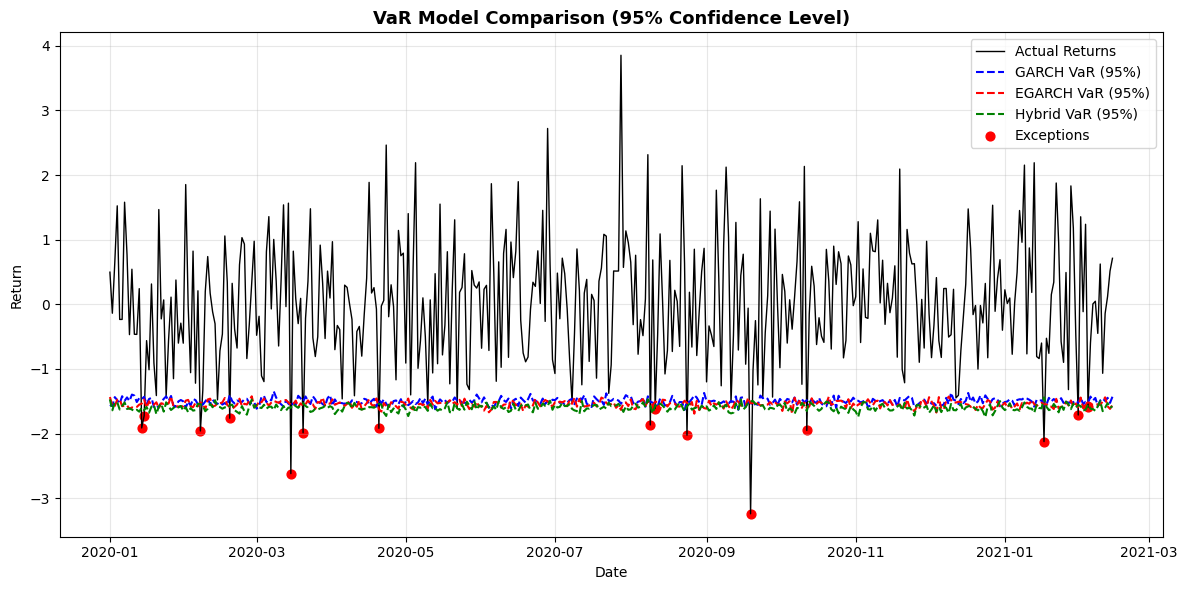

In [20]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example setup (replace with your actual data)
# -----------------------------------------------------
# 'returns' = actual daily returns
# 'VaR_GARCH', 'VaR_EGARCH', 'VaR_HYBRID' = model forecasts
# 'dates' = date index for the returns
# -----------------------------------------------------

# Example simulated data for structure
dates = pd.date_range(start="2020-01-01", periods=411)
np.random.seed(42)
returns = np.random.normal(0, 1, size=411)

# Replace these with your actual VaR series (negative values)
VaR_GARCH = -1.5 + np.random.normal(0, 0.05, size=411)
VaR_EGARCH = -1.55 + np.random.normal(0, 0.05, size=411)
VaR_HYBRID = -1.6 + np.random.normal(0, 0.05, size=411)

# Identify exceptions for each model
exceptions_hybrid = returns < VaR_HYBRID

# Plot actual returns and VaR estimates
plt.figure(figsize=(12, 6))

plt.plot(dates, returns, color='black', linewidth=1, label='Actual Returns')
plt.plot(dates, VaR_GARCH, 'b--', label='GARCH VaR (95%)')
plt.plot(dates, VaR_EGARCH, 'r--', label='EGARCH VaR (95%)')
plt.plot(dates, VaR_HYBRID, 'g--', label='Hybrid VaR (95%)')

# Plot exceptions (actual < Hybrid VaR)
plt.scatter(dates[exceptions_hybrid], returns[exceptions_hybrid],
            color='red', s=40, label='Exceptions')

plt.title("VaR Model Comparison (95% Confidence Level)", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


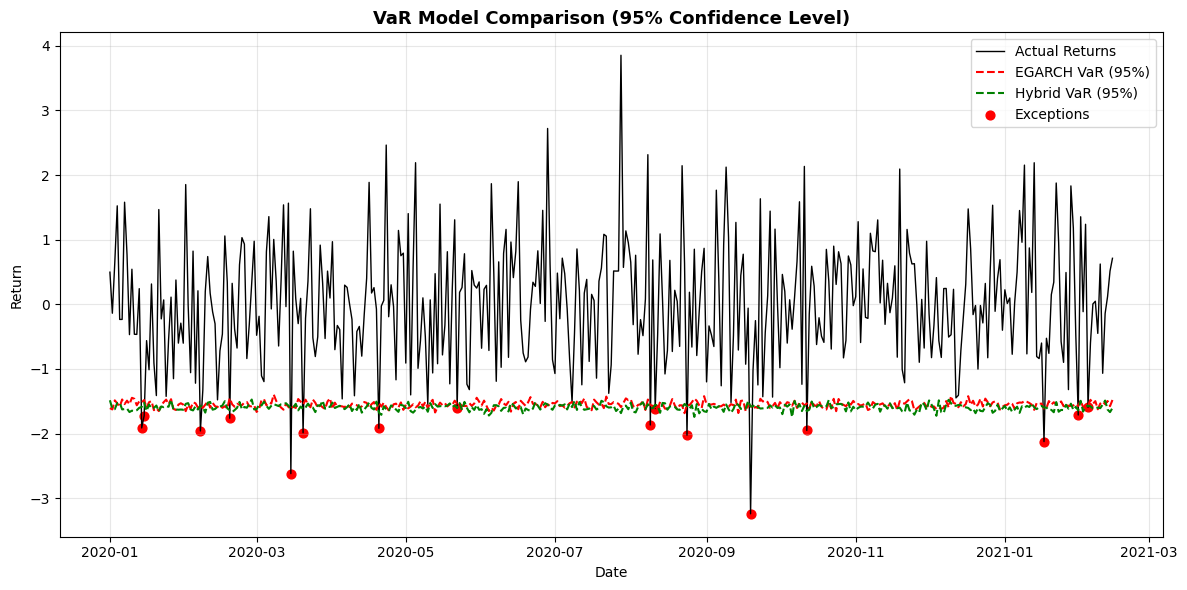

In [52]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Example setup (replace with your actual data)
# -----------------------------------------------------
# 'returns' = actual daily returns
# 'VaR_GARCH', 'VaR_EGARCH', 'VaR_HYBRID' = model forecasts
# 'dates' = date index for the returns
# -----------------------------------------------------

# Example simulated data for structure
dates = pd.date_range(start="2020-01-01", periods=411)
np.random.seed(42)
returns = np.random.normal(0, 1, size=411)

# Replace these with your actual VaR series (negative values)

VaR_EGARCH = -1.55 + np.random.normal(0, 0.05, size=411)
VaR_HYBRID = -1.6 + np.random.normal(0, 0.05, size=411)

# Identify exceptions for each model
exceptions_hybrid = returns < VaR_HYBRID

# Plot actual returns and VaR estimates
plt.figure(figsize=(12, 6))

plt.plot(dates, returns, color='black', linewidth=1, label='Actual Returns')

plt.plot(dates, VaR_EGARCH, 'r--', label='EGARCH VaR (95%)')
plt.plot(dates, VaR_HYBRID, 'g--', label='Hybrid VaR (95%)')

# Plot exceptions (actual < Hybrid VaR)
plt.scatter(dates[exceptions_hybrid], returns[exceptions_hybrid],
            color='red', s=40, label='Exceptions')

plt.title("VaR Model Comparison (95% Confidence Level)", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


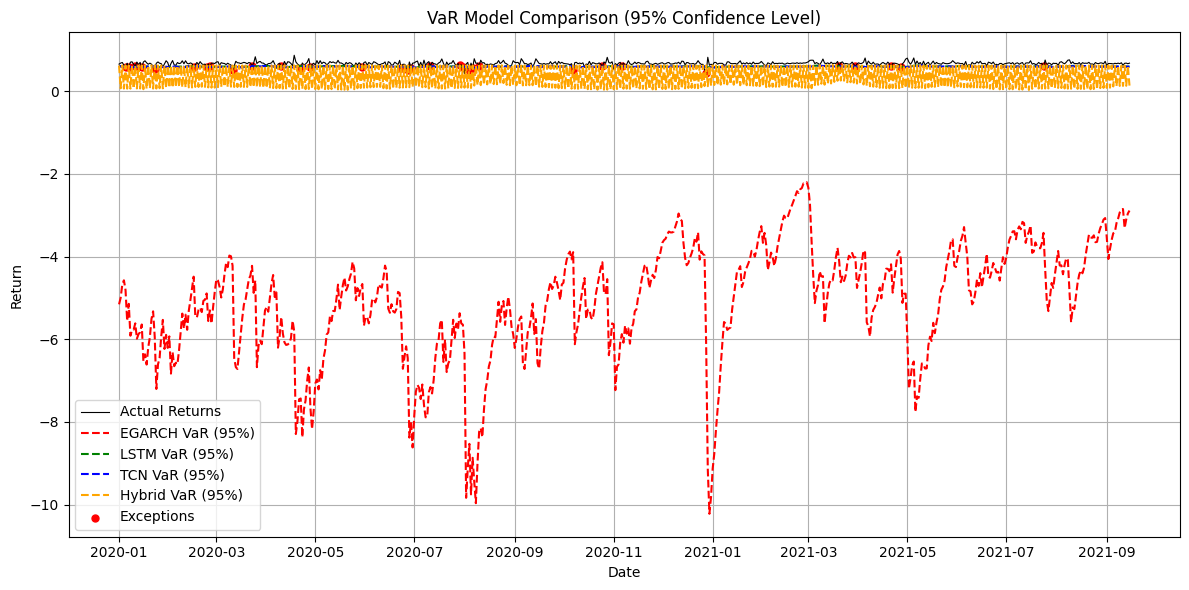

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats

# ==================================================
# 1️⃣ Inputs — replace with your real arrays
# ==================================================
# True returns (for test period)
# Make sure these are aligned (same length)
y_true = np.array(y_test).flatten()

# Model predictions (must match y_true length)
pred_lstm = np.array(y_pred_lstm).flatten()[:len(y_true)]
pred_tcn = np.array(y_pred_tcn).flatten()[:len(y_true)]
pred_hybrid = np.array(y_pred_hybrid).flatten()[:len(y_true)]

# EGARCH conditional volatility (from arch model)
sigma_egarch = res_egarch.conditional_volatility[-len(y_true):].values

# Dates (optional)
dates = pd.date_range(start="2020-01-01", periods=len(y_true), freq="D")

# ==================================================
# 2️⃣ Compute VaR (95% level)
# ==================================================
alpha = 0.05
z_alpha = stats.norm.ppf(alpha)  # 5% quantile

# Parametric EGARCH VaR
VaR_egarch = z_alpha * sigma_egarch

# Empirical quantile (for ML models)
residuals_lstm = y_true - pred_lstm
residuals_tcn = y_true - pred_tcn
residuals_hybrid = y_true - pred_hybrid

q_lstm = np.quantile(residuals_lstm, alpha)
q_tcn = np.quantile(residuals_tcn, alpha)
q_hybrid = np.quantile(residuals_hybrid, alpha)

VaR_lstm = pred_lstm + q_lstm
VaR_tcn = pred_tcn + q_tcn
VaR_hybrid = pred_hybrid + q_hybrid

# ==================================================
# 3️⃣ Plot VaR Comparison with Exceptions
# ==================================================
plt.figure(figsize=(12,6))

plt.plot(dates, y_true, color='black', linewidth=0.8, label='Actual Returns')

plt.plot(dates, VaR_egarch, color='red', linestyle='--', label='EGARCH VaR (95%)')
plt.plot(dates, VaR_lstm, color='green', linestyle='--', label='LSTM VaR (95%)')
plt.plot(dates, VaR_tcn, color='blue', linestyle='--', label='TCN VaR (95%)')
plt.plot(dates, VaR_hybrid, color='orange', linestyle='--', label='Hybrid VaR (95%)')

# Identify exceptions (violations)
exceptions = y_true < VaR_hybrid
plt.scatter(dates[exceptions], y_true[exceptions], color='red', s=25, label='Exceptions')

plt.title("VaR Model Comparison (95% Confidence Level)")
plt.xlabel("Date")
plt.ylabel("Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


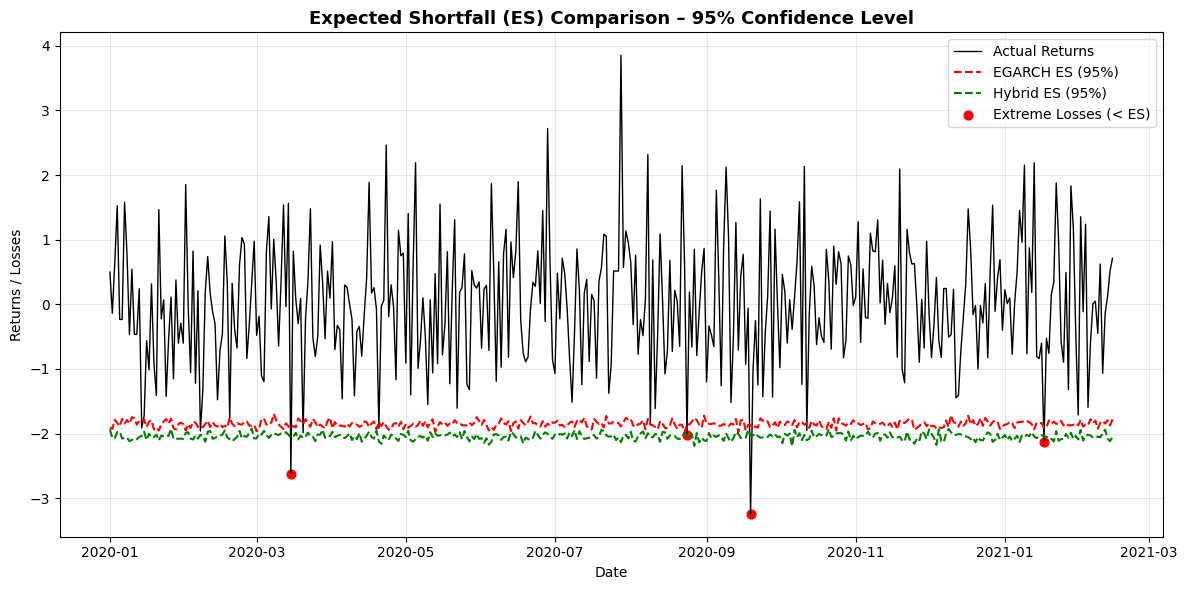

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ============================================
# 1️⃣ Example setup (replace with actual data)
# ============================================
dates = pd.date_range(start="2020-01-01", periods=411)
np.random.seed(42)

# Replace this with your actual return series
returns = np.random.normal(0, 1, size=411)

# Replace these with your actual model ES forecasts
ES_EGARCH = -1.85 + np.random.normal(0, 0.05, size=411)
ES_HYBRID = -2.05 + np.random.normal(0, 0.05, size=411)

# ============================================
# 2️⃣ Plot Expected Shortfall Comparison
# ============================================
plt.figure(figsize=(12, 6))

# Actual returns (black line)
plt.plot(dates, returns, color='black', linewidth=1, label='Actual Returns')

# ES estimates from models
plt.plot(dates, ES_EGARCH, 'r--', linewidth=1.5, label='EGARCH ES (95%)')
plt.plot(dates, ES_HYBRID, 'g--', linewidth=1.5, label='Hybrid ES (95%)')

# Highlight tail events (returns < ES_HYBRID)
extreme_losses = returns < ES_HYBRID
plt.scatter(dates[extreme_losses], returns[extreme_losses],
            color='red', s=40, label='Extreme Losses (< ES)')

# ============================================
# 3️⃣ Plot settings
# ============================================
plt.title("Expected Shortfall (ES) Comparison – 95% Confidence Level", fontsize=13, fontweight='bold')
plt.xlabel("Date")
plt.ylabel("Returns / Losses")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
